# Análise Exploratória de Dados
**Dataset:** Titanic

Neste *notebook*, vamos traduzir os conceitos teóricos de Análise Exploratória de Dados (EDA) em demonstrações práticas. O objetivo não é modelar, mas sim investigar: entender a incompletude, os tipos de dados reais *versus* os tipos em memória, desvendar estatísticas resumidas e levantar hipóteses visuais.

In [2]:
# Importação das bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px # Alternativa moderna para gráficos interativos

# Configuração visual padrão para os gráficos estáticos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Carregamento do dataset Titanic (disponível nativamente no Seaborn)
df = sns.load_dataset('titanic')

## Tipos em Memória vs. Tipos Estatísticos
Uma das primeiras armadilhas da EDA é confiar cegamente nos tipos de dados que o computador atribui às variáveis. A semântica importa.

In [3]:
# Visão geral estrutural
display(df.head(3))
print("-" * 50)
df.info()

# Demonstração: 'pclass' está guardado como int64 (computacionalmente contínuo/discreto numérico),
# mas estatisticamente é uma Categórica Ordinal.
print("\nValores únicos em 'pclass':", df['pclass'].unique())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB

Valores únicos em 'pclass': [3 1 2]


## Dados Incompletos: A ausência carrega informação?
Valores nulos (`NaN`) não são meros erros. Eles contam uma história sobre a recolha dos dados.

Valores ausentes por coluna:
 age            177
embarked         2
deck           688
embark_town      2
dtype: int64


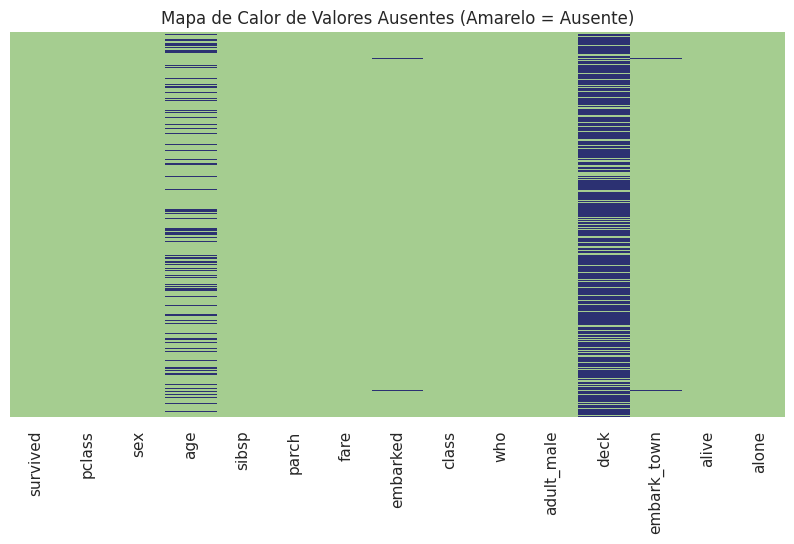

In [4]:
# Quantificação de dados ausentes
ausentes = df.isnull().sum()
print("Valores ausentes por coluna:\n", ausentes[ausentes > 0])

# Visualização da matriz de nulidade
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='crest')
plt.title('Mapa de Calor de Valores Ausentes (Amarelo = Ausente)')
plt.show()

# Hipótese: A cabine ('deck') tem demasiados valores ausentes. Estará relacionado com a classe do bilhete?

## Estatísticas que Enganam
Média, mediana e desvio-padrão comprimem a realidade. Vamos focar-nos na distribuição real dos dados, explorando **Variáveis Contínuas** e os conceitos de **Quantis e Boxplots**.

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64


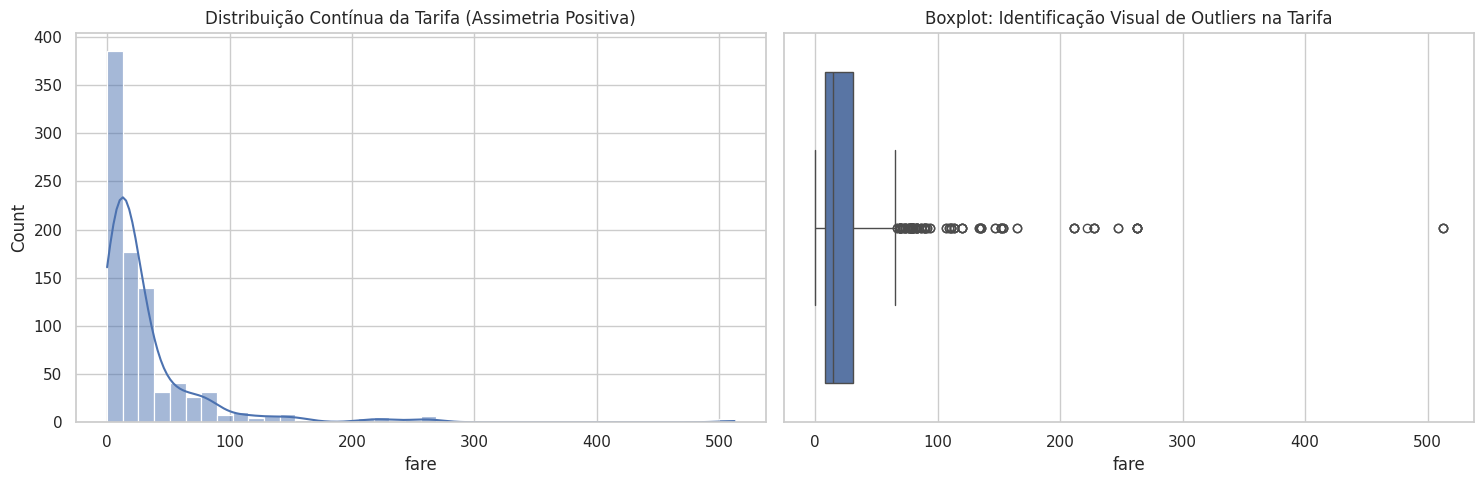

In [5]:
# Estatísticas descritivas básicas da variável 'fare' (Tarifa - Numérica Contínua)
print(df['fare'].describe())

# A média é ~32, mas o valor máximo é 512. A média está a esconder a assimetria!
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma: Visão da forma da distribuição
sns.histplot(df['fare'], bins=40, kde=True, ax=axes[0])
axes[0].set_title('Distribuição Contínua da Tarifa (Assimetria Positiva)')

# Boxplot: Excelente para visualizar quantis (25%, 50%, 75%) e outliers extremos
sns.boxplot(x=df['fare'], ax=axes[1])
axes[1].set_title('Boxplot: Identificação Visual de Outliers na Tarifa')

plt.tight_layout()
plt.show()

## Padrões Visuais como Hipóteses (Análise Multivariada)
Vamos cruzar variáveis para formular hipóteses sobre a sobrevivência. Lembramos: correlação visual não é causalidade, é o ponto de partida para a modelagem.

# Hipótese: A taxa de sobrevivência variou por Classe e Sexo?




In [ ]:
# Preparar os dados para o gráfico interativo
taxa_sobrevivencia = df.groupby(['pclass', 'sex'])['survived'].mean().reset_index()

# Gráfico interativo com Plotly
fig = px.bar(taxa_sobrevivencia, x='pclass', y='survived', color='sex', barmode='group',
             labels={'pclass': 'Classe do Bilhete', 'survived': 'Taxa de Sobrevivência', 'sex': 'Sexo'},
             title='Hipótese Interativa: Taxa de Sobrevivência por Classe e Sexo',
             color_discrete_map={'male': '#1f77b4', 'female': '#e377c2'})
fig.update_layout(yaxis_tickformat='.0%')
fig.show()

### Boxplots Multivariados
Vamos juntar uma variável Contínua (`age`), uma Ordinal (`pclass`) e uma Binária (`survived`).

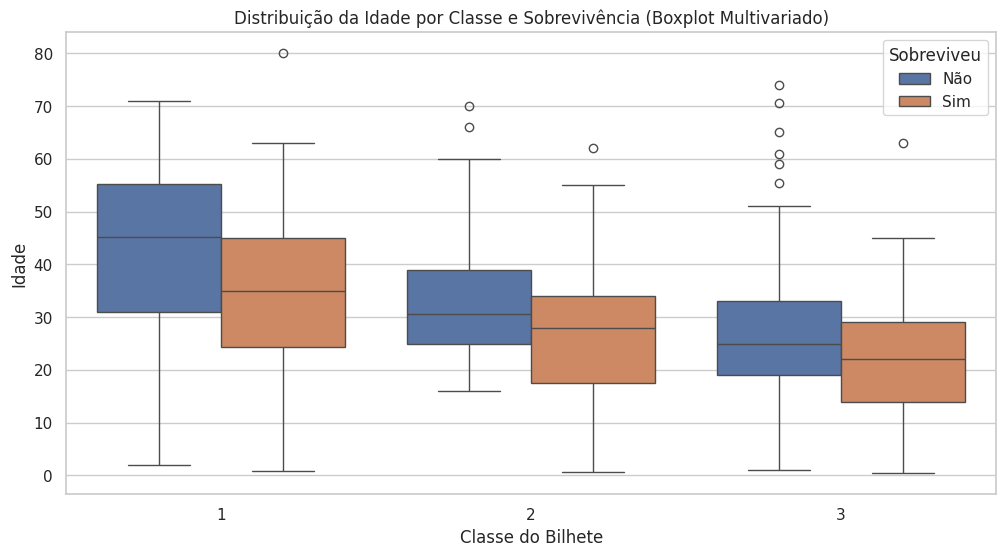

In [8]:
plt.figure(figsize=(12, 6))

# Armazenamos o objeto do eixo (ax) gerado pelo seaborn
ax = sns.boxplot(x='pclass', y='age', hue='survived', data=df)

plt.title('Distribuição da Idade por Classe e Sobrevivência (Boxplot Multivariado)')
plt.xlabel('Classe do Bilhete')
plt.ylabel('Idade')

# Extraímos os 'handles' (as cores/formas) e ignoramos os rótulos originais (0 e 1)
handles, _ = ax.get_legend_handles_labels()

# Recriamos a legenda mapeando explicitamente os handles extraídos para os novos rótulos
plt.legend(handles=handles, labels=['Não', 'Sim'], title='Sobreviveu')

plt.show()

Observações:
1. Os passageiros da 1ª classe eram, em média, mais velhos.
2. Na 2ª e 3ª classes, os sobreviventes tendem a ter uma mediana de idade ligeiramente inferior (possível prioridade a crianças).

## Automação da EDA com YData Profiling
Embora a inspeção manual seja fundamental para o raciocínio crítico, na prática do dia a dia (e em *pipelines* complexos), utilizamos bibliotecas de *Automated EDA* para acelerar a deteção de valores ausentes, correlações e distribuições.

In [ ]:
!pip install ydata_profiling

In [ ]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Relatório EDA - Titanic")
profile.to_notebook_iframe()

## Exemplo Off-Topic: Datasets no Mundo Real
Este é um exemplo clássico de um *dataset* real que não possui qualquer preparo estrutural. A formatação voltada para leitura humana em planilhas dificulta a ingestão programática e a análise exploratória direta.

**Exercício**: Tente aplicar os métodos que veremos durante essa aula à este dataset e compartilhe os resultados conseguidos.



In [9]:
# Leitura de um arquivo Excel bruto (necessita do pacote xlrd ou openpyxl)
fbi_citus_2010 = "sample_data/fbi_citus_2010.xls"
fbi_citus_2010_df = pd.read_excel(fbi_citus_2010)
display(fbi_citus_2010_df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'sample_data/fbi_citus_2010.xls'

**Nota**: A exibição mostrará cabeçalhos mesclados, linhas em branco como NaN e
metadados textuais misturados com dados tabulares. O passo zero aqui seria a limpeza.

# Hipótese: A idade possui influência nas chances de sobrevivência?
Iremos avaliar dois métodos para gerar um threshold de referência para classificar pessoas como jovens ou idosas e verificar nossa hipótese.
1. No primeiro método utilizaremos as próprias entradas do dataset e para calcular uma média interna que, portanto, possue um forte viés econômico prévio.
2. No segundo método, iremos utilizar a metade da expectativa média de vida da eṕoca (século XIV).

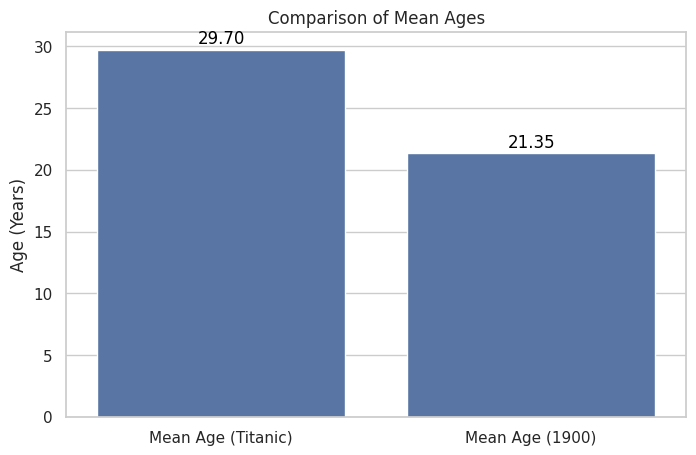

In [10]:
mean_age = df['age'].mean()
general_mean_age_1900 = 42.7 / 2

ages_labels = ['Mean Age (Titanic)', 'Mean Age (1900)']
ages_values = [mean_age, general_mean_age_1900]

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=ages_labels, y=ages_values)
plt.title('Comparison of Mean Ages')
plt.ylabel('Age (Years)')

for index, value in enumerate(ages_values):
    ax.text(index, value + 0.5, f'{value:.2f}', color='black', ha="center")

plt.show()

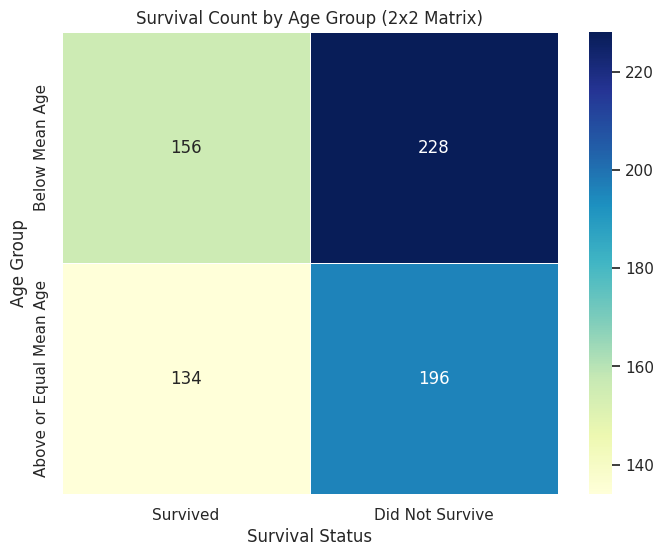

In [11]:
below_mean_age = df[df['age'] < mean_age]
above_or_equal_mean_age = df[df['age'] >= mean_age]

survived_below_mean = below_mean_age['survived'].sum()
not_survived_below_mean = len(below_mean_age) - survived_below_mean

survived_above_mean = above_or_equal_mean_age['survived'].sum()
not_survived_above_mean = len(above_or_equal_mean_age) - survived_above_mean

matrix_data = pd.DataFrame({
    'Survived': [survived_below_mean, survived_above_mean],
    'Did Not Survive': [not_survived_below_mean, not_survived_above_mean]
}, index=['Below Mean Age', 'Above or Equal Mean Age'])

plt.figure(figsize=(8, 6))
sns.heatmap(matrix_data, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)
plt.title('Survival Count by Age Group (2x2 Matrix)')
plt.xlabel('Survival Status')
plt.ylabel('Age Group')
plt.show()

In [12]:
total_young = len(below_mean_age)
died_young = not_survived_below_mean
mortality_young_percent = (died_young / total_young) * 100 if total_young > 0 else 0

total_old = len(above_or_equal_mean_age)
died_old = not_survived_above_mean
mortality_old_percent = (died_old / total_old) * 100 if total_old > 0 else 0

print(f"Mortality Rates (based on mean age of {mean_age:.2f})")
print(f"Percentage of young people (below {mean_age:.2f}) who died: {mortality_young_percent:.2f}%")
print(f"Percentage of old people (above or equal to {mean_age:.2f}) who died: {mortality_old_percent:.2f}%")

Mortality Rates (based on mean age of 29.70)
Percentage of young people (below 29.70) who died: 59.38%
Percentage of old people (above or equal to 29.70) who died: 59.39%


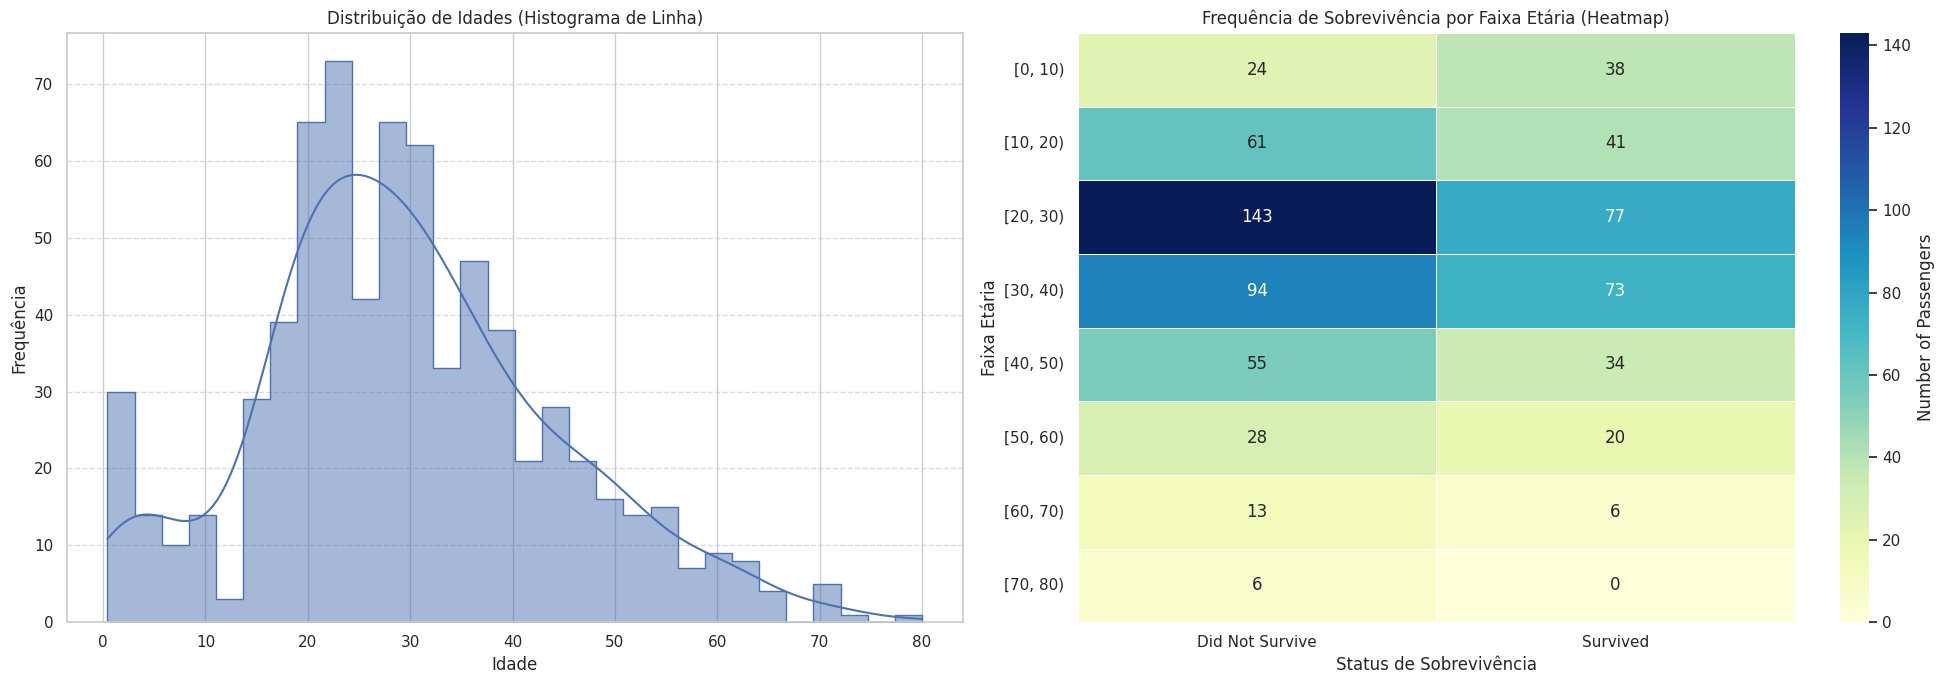

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Plot 1: Line Histogram
sns.histplot(df['age'], bins=30, kde=True, element='step', ax=axes[0])
axes[0].set_title('Distribuição de Idades (Histograma de Linha)')
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('Frequência')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Prepare data for heatmap
age_bins = pd.cut(df['age'], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80], right=False)
age_survival_counts = pd.crosstab(age_bins, df['survived'])
age_survival_counts.columns = ['Did Not Survive', 'Survived']

# Plot 2: Heatmap
sns.heatmap(age_survival_counts, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5, cbar_kws={'label': 'Number of Passengers'}, ax=axes[1])
axes[1].set_title('Frequência de Sobrevivência por Faixa Etária (Heatmap)')
axes[1].set_xlabel('Status de Sobrevivência')
axes[1].set_ylabel('Faixa Etária')
axes[1].tick_params(axis='y', labelrotation=0)

plt.tight_layout()
plt.show()

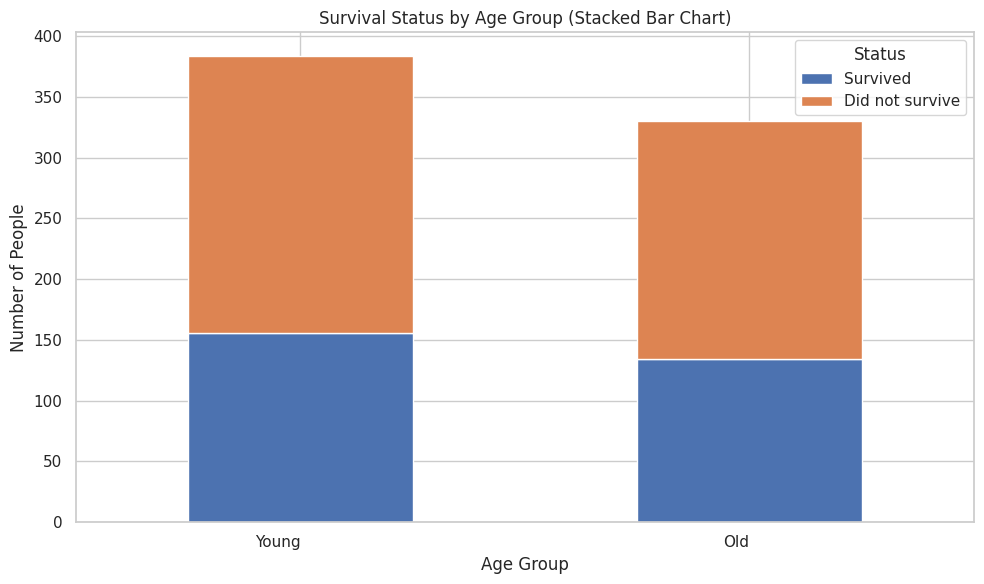

In [14]:
data = {
    'Age Group': ['Young', 'Old'],
    'Survived': [survived_below_mean, survived_above_mean],
    'Did not survive': [not_survived_below_mean, not_survived_above_mean]
}
df_plot = pd.DataFrame(data)

df_plot.set_index('Age Group').plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Survival Status by Age Group (Stacked Bar Chart)')
plt.ylabel('Number of People')
plt.xticks(rotation=0, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

## Binarizando dados categóricos com One-Hot Encoding
One-Hot Encoding é uma técnica de pré-processamento de dados utilizada em machine learning para converter variáveis categóricas nominais em uma representação numérica binária.

A técnica consiste em criar uma nova coluna (ou feature) para cada categoria única presente na variável original. Para cada observação, a coluna correspondente à sua categoria recebe o valor 1 (ativo/quente), enquanto todas as outras colunas recebem o valor 0 (inativo/frio).

### Como Funciona
Se você tem uma variável categórica `canal_de_cor` que possui entre seus valores possíveis `"vermelho"`, `"azul"` e `"verde"`, o algorítmo irá transformar essa variável única em três colunas binárias com 1 representando um canal ativo (quente), ou 0, representando um canal inativo (frio).

### Por que é necessário?
A grande maioria dos algoritmos matemáticos e computacionais exige vetores e matrizes numéricas como entrada. A alternativa mais simples para categorizar texto, atribuir um número inteiro seqüencial para cada categoria (ex: Vermelho=1, Verde=2, Azul=3), frequentemente induz os modelos de machine learning ao erro.

O modelo interpretaria matematicamente que existe uma relação de ordem ou magnitude (ex: assumindo que Azul é "maior" que Vermelho, ou que Verde é a média entre eles). O One-Hot Encoding resolve esse problema projetando as categorias em um espaço ortogonal, tornando todas elas equidistantes.

### Aplicando One-Hot Encoding

In [15]:
df['is_below_mean_age'] = (df['age'] < mean_age).astype(int)
display(df[['age', 'is_below_mean_age']].head())

,age,is_below_mean_age
0,22.0,1
1,38.0,0
2,26.0,1
3,35.0,0
4,35.0,0


### One-Hot Encoding para as faixas etárias (`age_bins`)

In [16]:
age_bins_encoded = pd.get_dummies(age_bins, prefix='age_group')
display(age_bins_encoded.head())

,"age_group_[0, 10)","age_group_[10, 20)","age_group_[20, 30)","age_group_[30, 40)","age_group_[40, 50)","age_group_[50, 60)","age_group_[60, 70)","age_group_[70, 80)"
0,False,False,True,False,False,False,False,False
1,False,False,False,True,False,False,False,False
2,False,False,True,False,False,False,False,False
3,False,False,False,True,False,False,False,False
4,False,False,False,True,False,False,False,False
